In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sales_data.csv")
df.head()

,Date,Sales
0,2023-01-01,1200
1,2023-01-02,1250
2,2023-01-03,1230
3,2023-01-04,1300
4,2023-01-05,1350


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    49 non-null     datetime64[ns]
 1   Sales   49 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 912.0 bytes


In [4]:
df = df.sort_values('Date')

In [5]:
df.isnull().sum()

Date     0
Sales    0
dtype: int64

In [6]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

In [7]:
df.head(), df.tail()

(        Date  Sales
 0 2023-01-01   1200
 1 2023-01-02   1250
 2 2023-01-03   1230
 3 2023-01-04   1300
 4 2023-01-05   1350,
          Date  Sales
 44 2023-02-14   2800
 45 2023-02-15   2850
 46 2023-02-16   2900
 47 2023-02-17   2950
 48 2023-02-18   3000)

In [8]:
df.describe()

,Date,Sales
count,49,49.000000
mean,2023-01-25 00:00:00,2041.428571
min,2023-01-01 00:00:00,1200.000000
25%,2023-01-13 00:00:00,1600.000000
50%,2023-01-25 00:00:00,2000.000000
75%,2023-02-06 00:00:00,2480.000000
max,2023-02-18 00:00:00,3000.000000
std,NaN,524.408397


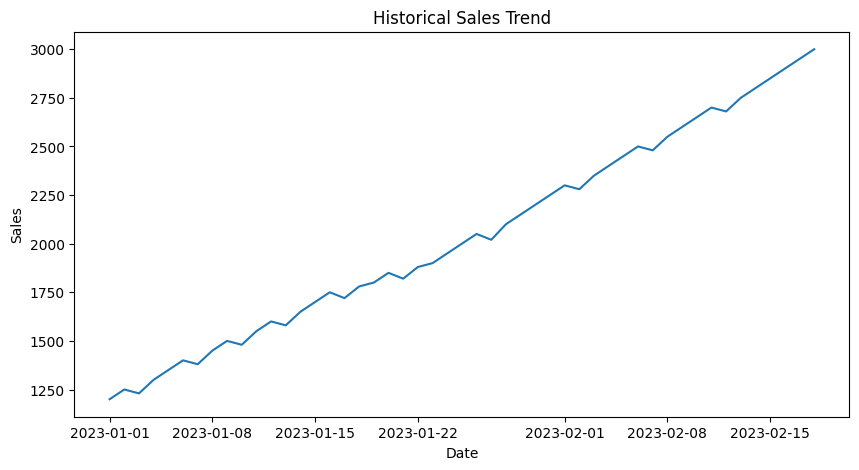

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Historical Sales Trend")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10612\1017852440.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Date').sum()


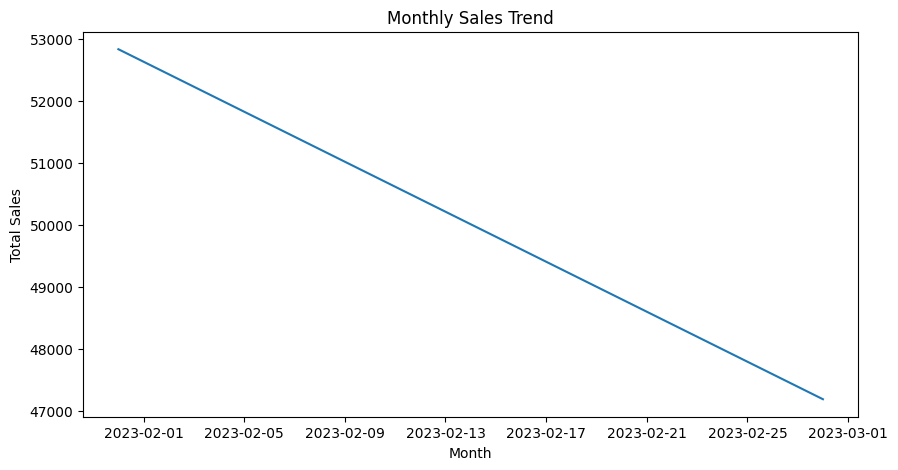

In [10]:
monthly_sales = df.resample('M', on='Date').sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales['Sales'])
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()

In [11]:
prophet_df = df.rename(columns={
    'Date': 'ds',
    'Sales': 'y'
})

prophet_df.head()

,ds,y
0,2023-01-01,1200
1,2023-01-02,1250
2,2023-01-03,1230
3,2023-01-04,1300
4,2023-01-05,1350


In [12]:
train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

print("Training data size:", len(train))
print("Testing data size:", len(test))

Training data size: 39
Testing data size: 10


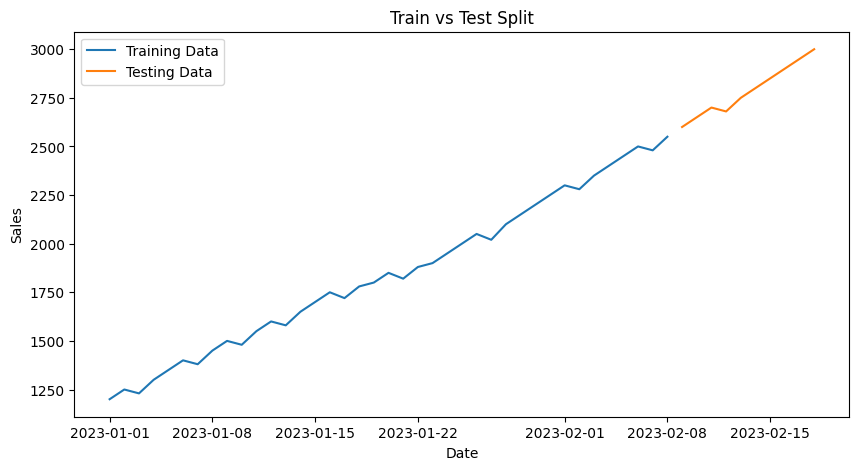

In [13]:
plt.figure(figsize=(10,5))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], test['y'], label='Testing Data')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Train vs Test Split")
plt.legend()
plt.show()

In [14]:
from prophet import Prophet

In [15]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [16]:
model.fit(train)

21:33:08 - cmdstanpy - INFO - Chain [1] start processing
21:33:11 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
future = model.make_future_dataframe(periods=len(test))
future.tail()

,ds
44,2023-02-14
45,2023-02-15
46,2023-02-16
47,2023-02-17
48,2023-02-18


In [18]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2023-01-01,1195.427631,1173.726208,1218.614890
1,2023-01-02,1245.761165,1221.706680,1268.628561
2,2023-01-03,1249.603257,1226.481610,1272.012551
3,2023-01-04,1311.599414,1288.529342,1335.191758
4,2023-01-05,1340.387557,1318.309939,1362.426502


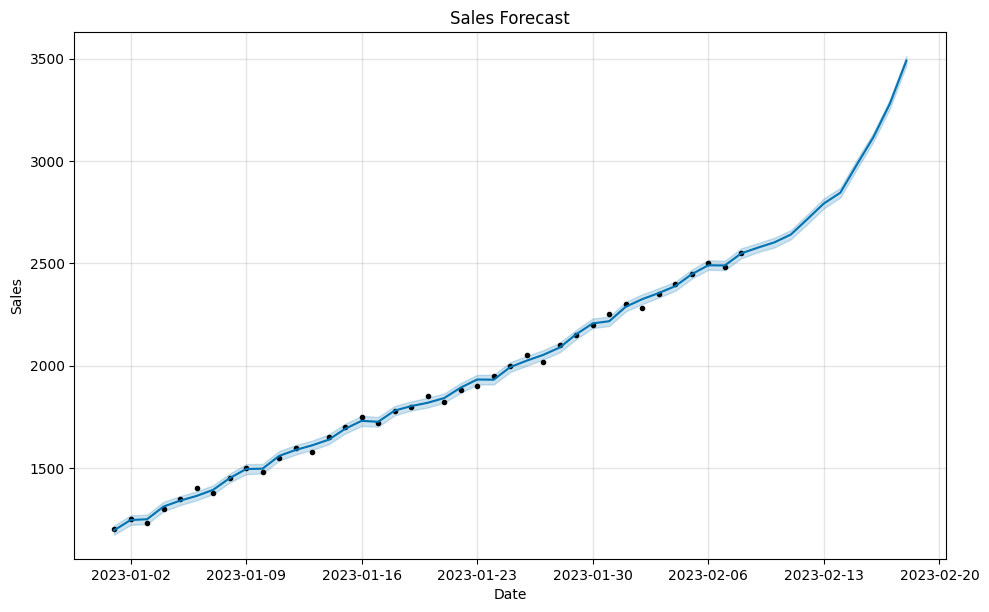

In [19]:
model.plot(forecast)
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

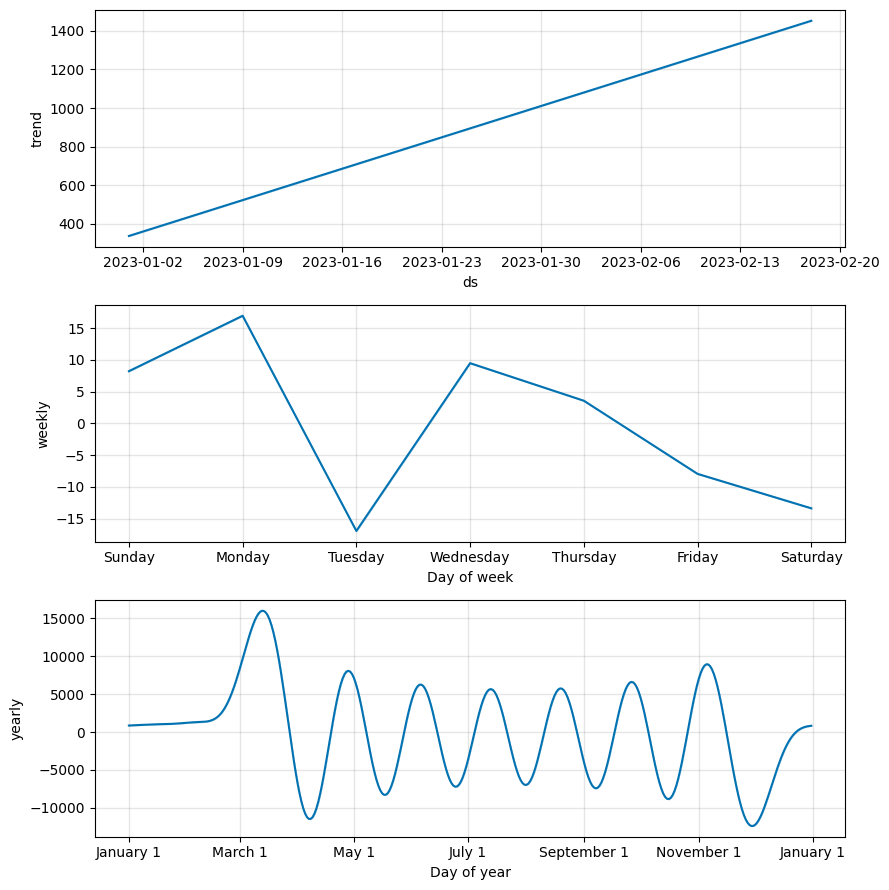

In [20]:
model.plot_components(forecast)
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [22]:
# Get predicted sales for test period
forecast_test = forecast[['ds', 'yhat']].iloc[len(train):]

actual = test['y'].values
predicted = forecast_test['yhat'].values

In [23]:
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 142.14
Root Mean Squared Error (RMSE): 205.97


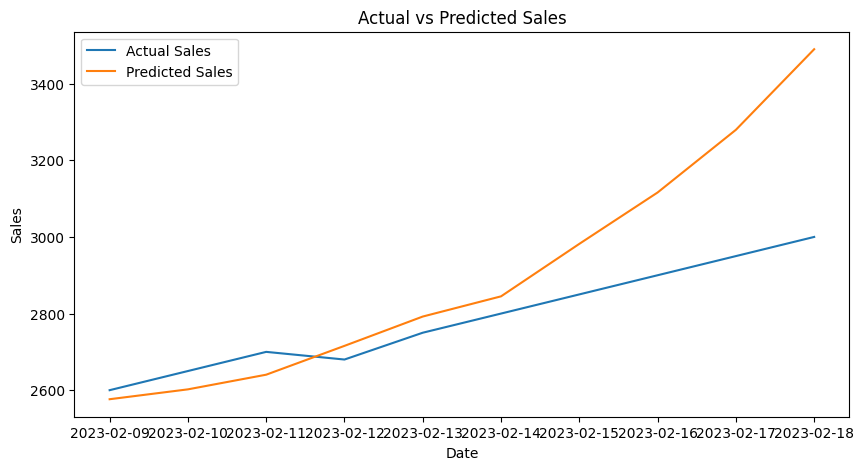

In [24]:
plt.figure(figsize=(10,5))
plt.plot(test['ds'], actual, label='Actual Sales')
plt.plot(test['ds'], predicted, label='Predicted Sales')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

In [25]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    "sales_forecast_output.csv", index=False
)

In [26]:
pd.read_csv("sales_forecast_output.csv").head()

,ds,yhat,yhat_lower,yhat_upper
0,2023-01-01,1195.427631,1173.726208,1218.614890
1,2023-01-02,1245.761165,1221.706680,1268.628561
2,2023-01-03,1249.603257,1226.481610,1272.012551
3,2023-01-04,1311.599414,1288.529342,1335.191758
4,2023-01-05,1340.387557,1318.309939,1362.426502
